# Groom-Bailey Decomposition

This notebook walks through the magnetotelluric Groom-Bailey decomposition contribution end-to-end: synthetic and real-data examples, multi-start mode discovery, parametric bootstrap, multi-site joint fitting, serialisation, and the limitations and future-work directions.

The eight sections are designed to be read in order on a first pass; later sections assume vocabulary and conventions introduced earlier. End-to-end runtime is roughly 5 minutes on a typical laptop with default parameters.

## 1. Introduction

The Groom-Bailey decomposition (Groom & Bailey 1989) is a tensor decomposition that separates the magnetotelluric impedance tensor into a 2-D regional response and a frequency-independent galvanic distortion. The factorisation is

$$
\mathbf{Z}_{\text{meas}} = R(\theta)\, g\, T(t)\, S(e)\, \mathbf{Z}_{2\mathrm{D}}\, R(\theta)^\top
$$

where $\theta$ is the regional strike, $g$ the static-shift gain, $T(t)$ the twist matrix, $S(e)$ the shear matrix, and $\mathbf{Z}_{2\mathrm{D}}$ the regional 2-D impedance. The recoverable parameters are the four scalar geometric quantities (strike, twist, shear, gain), the per-frequency regional impedances, and a non-identifiable anisotropy slot retained for parameter-vector symmetry.

This implementation is a NumPy/SciPy port of the Fortran Strike code (`~/MT_Decomp/strike61_xnag/`) augmented with three contributions absent from the historical reference:

- **Multi-start optimisation with mode discovery.** The Groom-Bailey objective surface is multi-modal in real-world settings. Single-start TRF lands in non-global basins on roughly half of real-data bands; multi-start with hybrid initialisation (canonical + 90°-rotated + random perturbations) materially improves global recovery and exposes mode ambiguities as first-class metadata.
- **Parametric bootstrap.** Per-replica resampling around the primary-mode prediction yields empirical confidence intervals for direct GB parameters. CIs derived from invariant quantities are flagged as formally meaningless per Chave (2014).
- **Multi-site joint optimisation.** A McNeice-Jones (2001)-style joint fit shares one regional strike across stations within a band while keeping per-station distortion and per-station per-frequency regional impedance.

Validation. The single-site implementation reduces to the joint code at `n_sites=1` bit-for-bit (residuals and Jacobian both at machine precision). Cross-validation against the Fortran reference on the canonical `strike_example` dataset achieves median azimuth error of 6.3° (under the 10° regression bound) with default `n_starts=5`.

**References.** Groom, R. W., & Bailey, R. C. (1989). *J. Geophys. Res.* 94(B2), 1913-1925. McNeice, G. W., & Jones, A. G. (2001). *Geophysics* 66(1), 158-173. Chave, A. D. (2014). *Geophys. J. Int.* 196(2), 1063-1076.

**Roadmap.** Section 2 starts with a synthetic example. Section 3 demonstrates multi-modal mode discovery. Section 4 covers parametric bootstrap. Section 5 demonstrates multi-site joint fitting. Section 6 walks through three real datasets. Section 7 covers save and load. Section 8 documents what this contribution does and does not claim.

## 2. Synthetic single-site example

We start with a synthetic problem where the truth is known. Build an impedance tensor from a chosen `(strike, twist, shear, gain)`, add a small amount of noise, decompose, and verify recovery.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mtpy.core.transfer_function.z import Z
from mtpy.core.transfer_function.z_analysis.decomposition import (
    decompose,
    decompose_joint,
    decompose_each_station,
    DecompositionResult,
    _estim_imp,
)
from mtpy.imaging.plot_decomposition import (
    PlotDecompositionStrikeRose,
    PlotDecompositionTwistShear,
    PlotDecompositionApparentResistivity,
    PlotDecompositionChiSquared,
    PlotDecompositionModeLandscape,
    PlotDecompositionBootstrap,
    plot_decomposition_summary,
)

rng = np.random.default_rng(42)

In [2]:
def build_synthetic_z(
    theta_deg, twist_deg, shear_deg, gain=1.0,
    n_periods=16, period_lo=-1, period_hi=2, noise=0.01, seed=42,
):
    """Build a synthetic Z with known GB parameters."""
    rng = np.random.default_rng(seed)
    periods = np.logspace(period_lo, period_hi, n_periods)
    theta = np.radians(theta_deg)
    twist = np.radians(twist_deg)
    shear = np.radians(shear_deg)

    mu0 = 4 * np.pi * 1e-7
    factor = 2 * np.pi * mu0
    log10_rho_a = rng.uniform(1.0, 2.0, n_periods)
    phase_a = np.radians(rng.uniform(35, 50, n_periods))
    log10_rho_b = rng.uniform(2.0, 3.0, n_periods)
    phase_b = np.radians(rng.uniform(35, 50, n_periods))

    z = np.empty((n_periods, 2, 2), dtype=complex)
    for k in range(n_periods):
        rho_a = 10 ** log10_rho_a[k]
        rho_b = 10 ** log10_rho_b[k]
        abs_a = np.sqrt(rho_a * factor / periods[k])
        abs_b = np.sqrt(rho_b * factor / periods[k])
        a_k = abs_a * np.exp(1j * phase_a[k])
        b_k = abs_b * np.exp(1j * phase_b[k])
        z[k] = gain * _estim_imp(a_k, b_k, np.tan(twist), np.tan(shear), theta)

    sigma = noise * np.abs(z) + 1e-15
    z = z + (rng.normal(scale=sigma) + 1j * rng.normal(scale=sigma))
    return Z(z=z, z_error=sigma, frequency=1.0 / periods)


TRUTH = dict(theta_deg=30.0, twist_deg=10.0, shear_deg=5.0, gain=1.5)
z_obj = build_synthetic_z(**TRUTH)
print(f"Synthetic Z: {len(z_obj.frequency)} periods, "
      f"period range {1/z_obj.frequency.max():.3g} - {1/z_obj.frequency.min():.3g} s")

Synthetic Z: 16 periods, period range 0.1 - 100 s


In [3]:
result = decompose(z_obj, n_starts=5, seed=42)

print(f"RMS misfit: {result.rms_misfit:.3g}")
print(f"Bands fitted: {result.metadata['n_bands']}")
print()
print(f"  Median strike: {float(result.parameters['strike'].median()):.2f} deg  (truth: {TRUTH['theta_deg']:.2f} deg)")
print(f"  Median twist:  {float(result.parameters['twist'].median()):.2f} deg  (truth: {TRUTH['twist_deg']:.2f} deg)")
print(f"  Median shear:  {float(result.parameters['shear'].median()):.2f} deg  (truth: {TRUTH['shear_deg']:.2f} deg)")
print(f"  Median gain:   {float(result.parameters['gain'].median()):.3f}      (truth: {TRUTH['gain']:.3f})")
print(f"  Primary mode warning: {result.metadata['primary_mode_warning']}")

RMS misfit: 0.649
Bands fitted: 3

  Median strike: 29.89 deg  (truth: 30.00 deg)
  Median twist:  9.96 deg  (truth: 10.00 deg)
  Median shear:  4.96 deg  (truth: 5.00 deg)
  Median gain:   1.003      (truth: 1.500)
  Primary mode warning: False


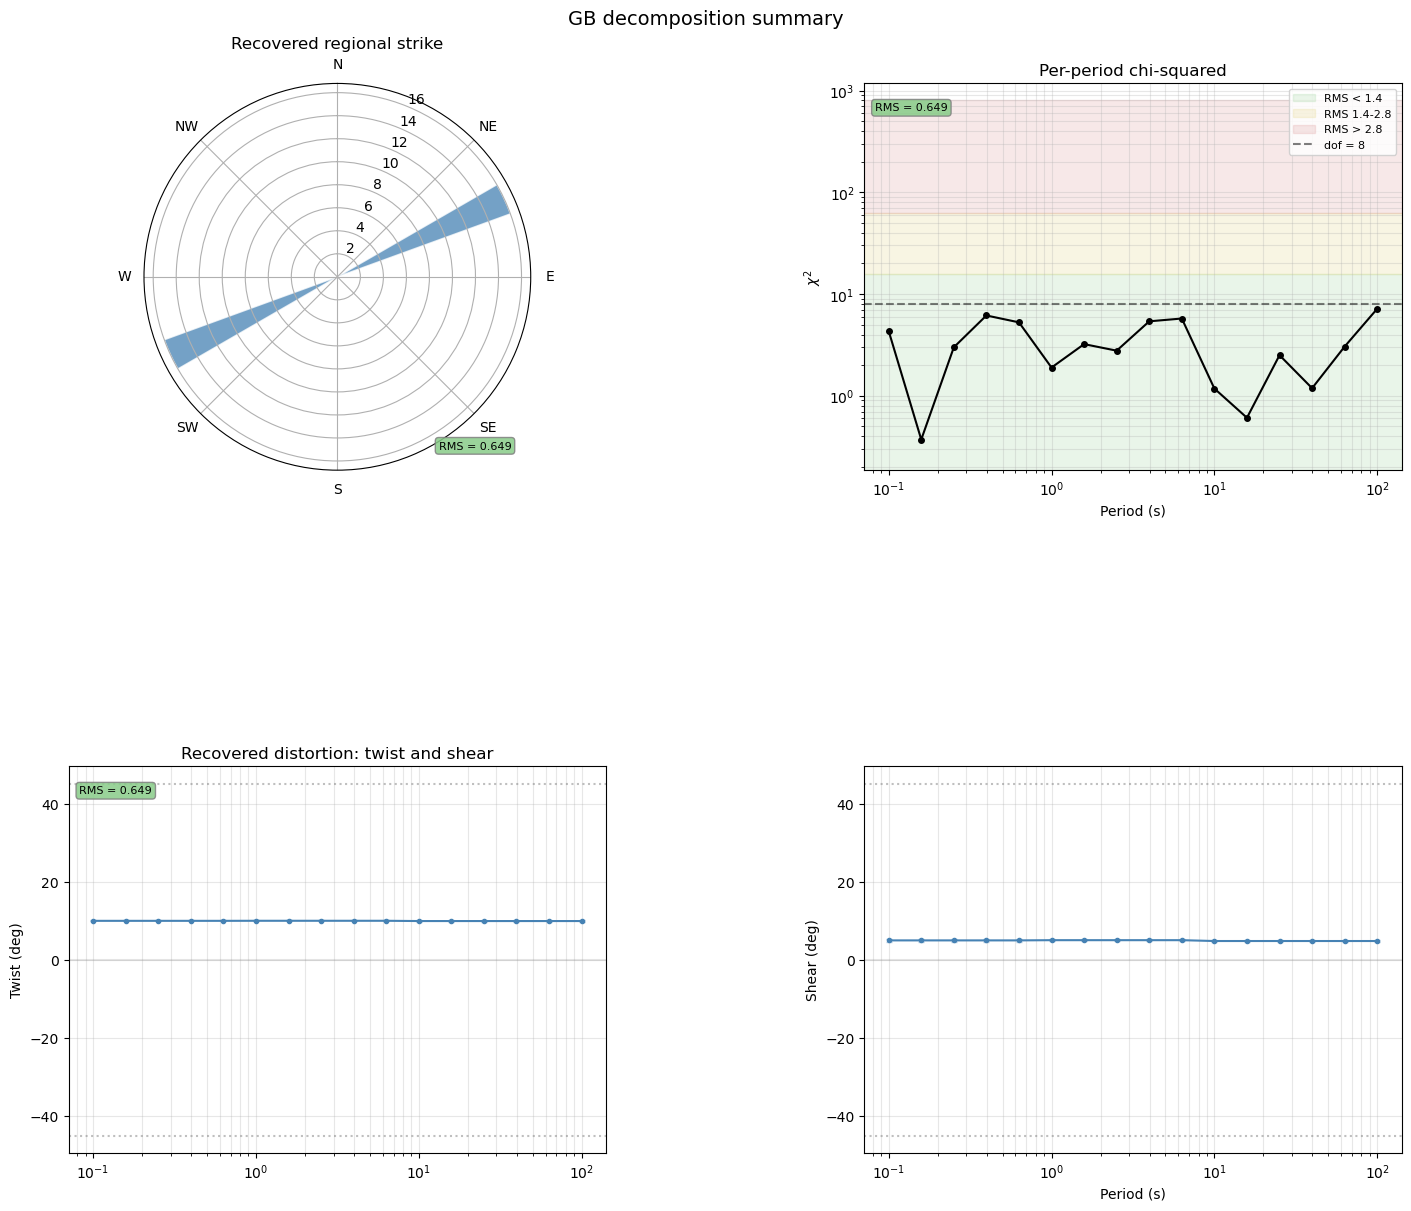

In [4]:
fig = plot_decomposition_summary(result, show_diagnostics=False)
plt.show()

What to look for:

- The strike rose concentrates near the true strike (30° in the canonical [0, 90°) fold).
- Twist and shear cluster around their true values; error bars are small.
- Apparent resistivity and phase show smooth, plausible MT responses.
- Chi-squared per period stays in the green regime (RMS < 1.4); the overall RMS is order-1.

This is the regime where the optimiser, the noise model, and the GB89 forward model all agree. Real data is more interesting; we get to that in section 6.

## 3. Multi-start and mode discovery

The Groom-Bailey objective surface is multi-modal: real datasets routinely have multiple physically-distinct solutions of comparable RMS. Single-start TRF would silently pick whichever basin it lands in; multi-start with hybrid initialisation surfaces the alternatives explicitly.

We construct a synthetic case where multi-modality is expected (strike near a 45° symmetry boundary often yields competing modes) and inspect what the contribution returns.

In [5]:
z_mm = build_synthetic_z(theta_deg=44.5, twist_deg=15.0, shear_deg=-8.0, seed=7)
result_mm = decompose(z_mm, n_starts=5, seed=42)

print(f"Bands: {result_mm.metadata['n_bands']}")
print(f"Primary mode warning: {result_mm.metadata['primary_mode_warning']}")
print()
for i, band_info in enumerate(result_mm.metadata['per_band']):
    print(f"Band {i} ({len(band_info['band_periods'])} periods, {band_info['n_modes']} modes):")
    for mode_i, mode in enumerate(band_info['modes']):
        cf = mode['canonical_form']
        print(
            f"  mode {mode_i}: strike={cf['strike_deg']:6.2f} deg, "
            f"RMS={mode['rms_misfit']:.4g}, prob={mode['probability']:.3f}"
        )

Bands: 3
Primary mode warning: False

Band 0 (5 periods, 2 modes):
  mode 0: strike= 44.78 deg, RMS=0.5571, prob=1.000
  mode 1: strike=  0.00 deg, RMS=32.57, prob=0.000
Band 1 (5 periods, 1 modes):
  mode 0: strike= 44.75 deg, RMS=0.6149, prob=1.000
Band 2 (6 periods, 1 modes):
  mode 0: strike= 44.34 deg, RMS=0.5348, prob=1.000


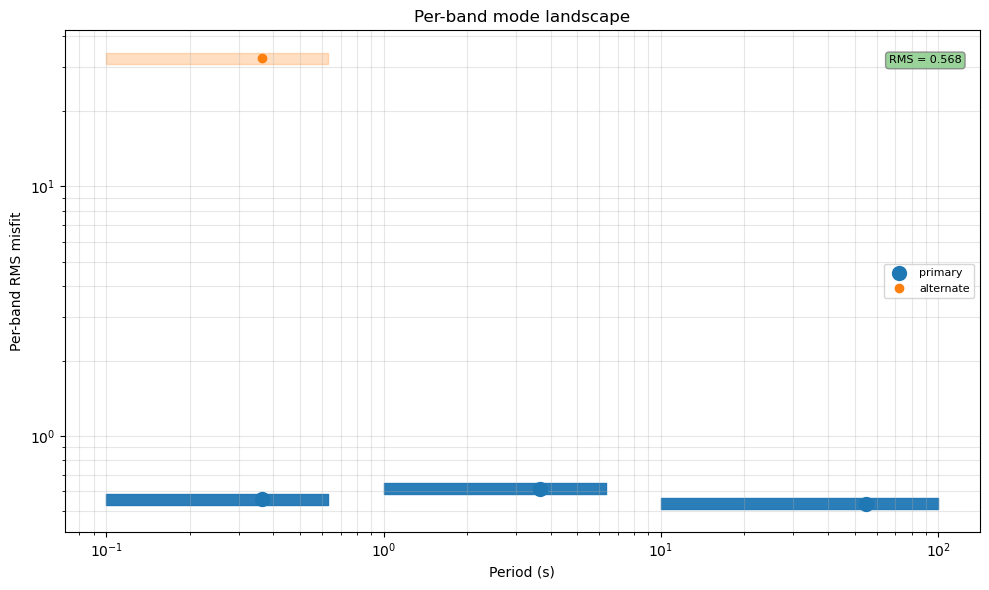

In [6]:
fig = PlotDecompositionModeLandscape(result_mm).plot()
plt.show()

Bars at the same period range with comparable heights (high mode probabilities at similar RMS) indicate competing physical solutions. When multiple modes are competitive, single-mode confidence intervals are misleading — the data is genuinely ambiguous, and that ambiguity should be carried through to interpretation rather than collapsed to a point estimate.

The strike rose plot also shows alternate modes (in lighter shading) when `primary_mode_warning` fires:

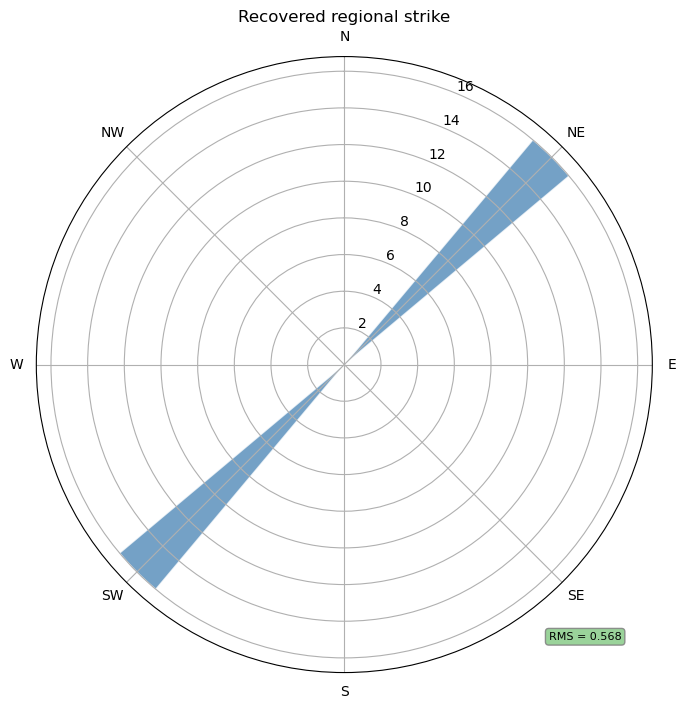

In [7]:
fig = PlotDecompositionStrikeRose(result_mm, show_alternates=True).plot()
plt.show()

## 4. Parametric bootstrap

Analytical errors come from the Jacobian at the converged optimum and assume the local likelihood surface is Gaussian. For real-world MT decompositions both assumptions can fail (model misspecification, multi-modality). Parametric bootstrap addresses this by resampling synthetic data around the primary-mode prediction and re-decomposing each replica; the empirical distribution of replicates is the bootstrap distribution.

We run 100 replicas on the section 2 synthetic. This takes 1-2 minutes.

In [8]:
result_bs = decompose(z_obj, n_starts=5, realisations=100, seed=42)

print(f"RMS misfit: {result_bs.rms_misfit:.3g}")
print(f"Replicas: {result_bs.metadata['bootstrap_realisations']}")
print(f"Replicas with mode warning: "
      f"{int(result_bs.metadata['bootstrap_mode_warning_fraction'] * 100)}%")
print()
print(f"Bootstrap 95% CI on strike (median across periods): "
      f"[{float(result_bs.parameters['strike_ci_lower'].median()):.2f}, "
      f"{float(result_bs.parameters['strike_ci_upper'].median()):.2f}] deg")
print(f"Analytical 1-sigma error on strike (median): "
      f"{float(result_bs.parameters['strike_error'].median()):.3f} deg")

RMS misfit: 0.649
Replicas: 100
Replicas with mode warning: 0%

Bootstrap 95% CI on strike (median across periods): [29.23, 30.44] deg
Analytical 1-sigma error on strike (median): 0.291 deg


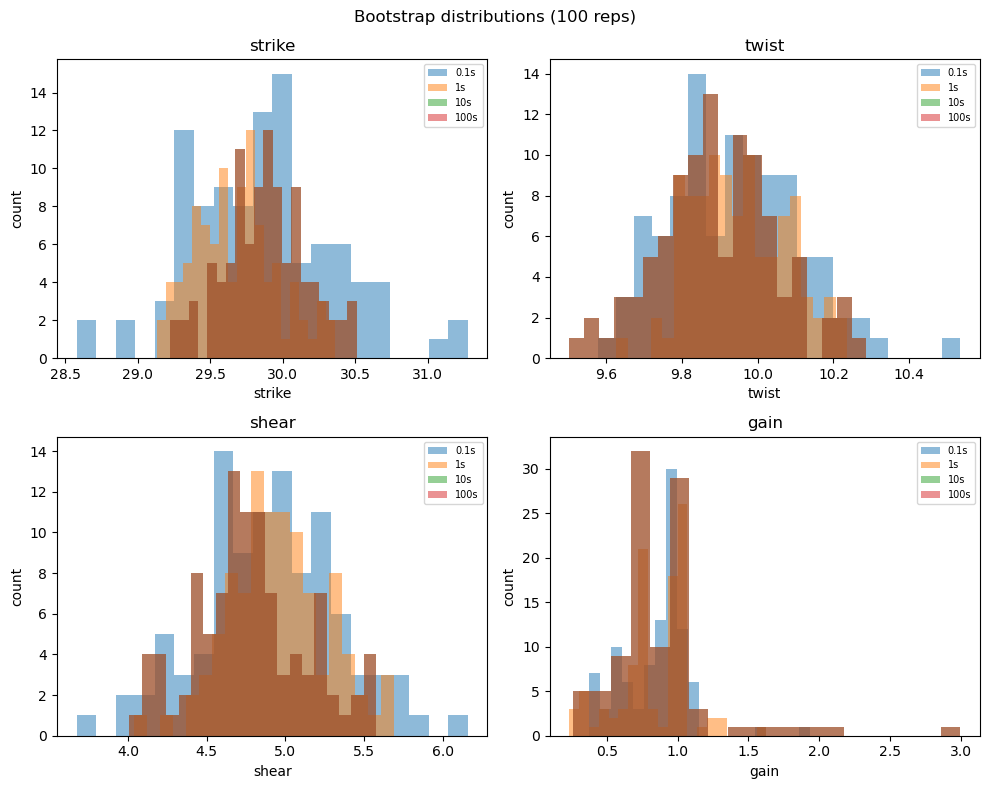

In [9]:
fig = PlotDecompositionBootstrap(result_bs).plot()
plt.show()

Histograms surface skew, multimodality, and other non-Gaussian structure that point-plus-symmetric-CI hides. **When to use which:**

- *Analytical 1-sigma errors* are appropriate when the residuals are well-fit (RMS ~ 1) and the Jacobian is well-conditioned. They are 100x faster to compute than bootstrap.
- *Bootstrap CIs* are appropriate when residuals indicate model misfit, when the optimisation surface is multi-modal, or when the user needs honest error bars for publication.

**Bootstrap caveats** (Chave 2014). Parametric bootstrap measures sensitivity under the assumption that the noise model and the GB89 forward model are correct. Model-misspecification uncertainty is not captured. Bootstrap CIs are reliable for *direct* GB parameters (strike, twist, shear, gain, regional Z components). CIs *derived* from these via phase-tensor invariants or Mohr-circle quantities are formally meaningless: those derived quantities have infinite asymptotic variance and are not amenable to bootstrap CI methods.

## 5. Multi-site joint decomposition

When multiple stations sample a common regional structure, joint fitting (McNeice & Jones 2001) shares the regional strike across stations within each band while keeping per-station distortion and per-station per-frequency regional impedance. Joint fitting produces tighter strike estimates when the shared-strike assumption holds; it is a poor fit when stations actually sample different geological domains.

We build three synthetic stations sharing strike but with distinct distortion.

In [10]:
class _MTLike:
    """Light wrapper sufficient for decompose_joint's input contract."""

    def __init__(self, station, z):
        self.station = station
        self.Z = z


joint_truth = dict(theta_deg=22.5, n_periods=12, period_lo=-1, period_hi=2)
synthetic_mts = []
for i, (twist, shear, gain) in enumerate([
    (8.0, 3.0, 1.0),
    (12.0, -5.0, 1.4),
    (-3.0, 7.0, 0.7),
]):
    z = build_synthetic_z(
        theta_deg=joint_truth['theta_deg'], twist_deg=twist,
        shear_deg=shear, gain=gain,
        n_periods=joint_truth['n_periods'],
        period_lo=joint_truth['period_lo'],
        period_hi=joint_truth['period_hi'],
        seed=10 + i,
    )
    synthetic_mts.append(_MTLike(f"STA{i+1:03d}", z))
print(f"Built {len(synthetic_mts)} synthetic stations sharing strike={joint_truth['theta_deg']} deg")

Built 3 synthetic stations sharing strike=22.5 deg


In [11]:
result_joint = decompose_joint(synthetic_mts, n_starts=3, seed=42)

print(f"Method: {result_joint.method}")
print(f"Stations: {result_joint.metadata['n_sites']}")
print(f"Bands: {result_joint.metadata['n_bands']}")
print(f"Median shared strike: "
      f"{float(result_joint.parameters['strike'].median()):.2f} deg "
      f"(truth: {joint_truth['theta_deg']:.2f} deg)")
print()
print("Per-station median twist / shear:")
for sid in result_joint.parameters.station.values:
    twist_med = float(result_joint.parameters['twist'].sel(station=sid).median())
    shear_med = float(result_joint.parameters['shear'].sel(station=sid).median())
    print(f"  {sid}: twist={twist_med:.2f} deg, shear={shear_med:.2f} deg")

Method: mcneice_jones_joint
Stations: 3
Bands: 3
Median shared strike: 22.66 deg (truth: 22.50 deg)

Per-station median twist / shear:
  STA001: twist=8.23 deg, shear=3.56 deg
  STA002: twist=11.99 deg, shear=-5.24 deg
  STA003: twist=-2.94 deg, shear=7.18 deg


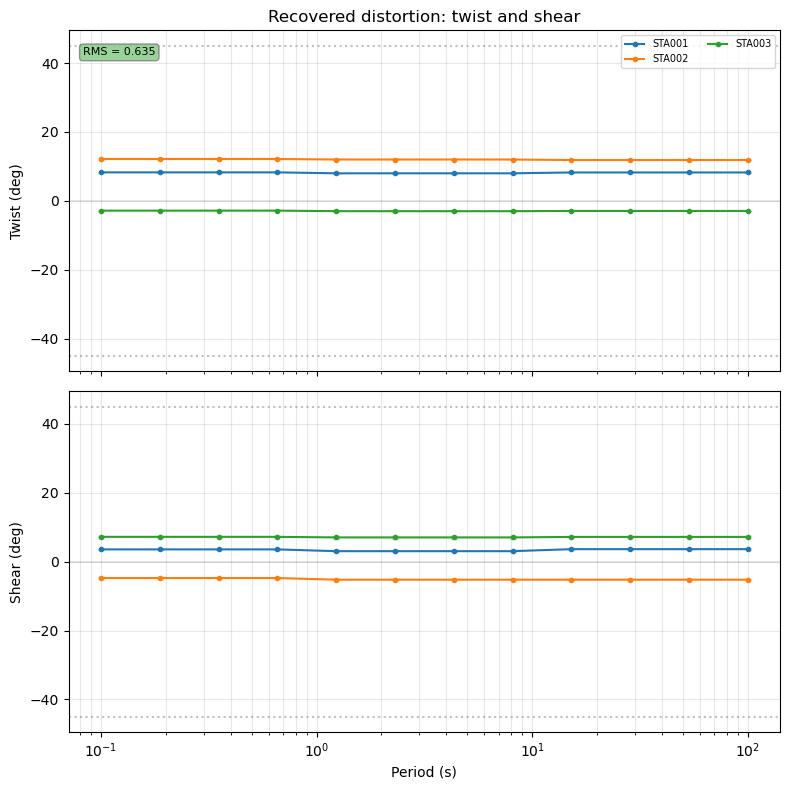

In [12]:
fig = PlotDecompositionTwistShear(result_joint).plot()
plt.show()

**When to use joint vs per-station independent.** Joint fitting is appropriate when stations are spatially close enough to sample the same regional geological structure (typical for tight arrays). For sparse surveys spanning more than ~50 km or surveys crossing geological boundaries, per-station `decompose_each_station` is more honest about strike heterogeneity.

**Cost.** Joint cost rises sharply with station count and band count. On real BBMT data with ~62 periods (5-7 bands) and 9 stations, joint with `n_starts=5` and no bootstrap takes about 19 minutes; with `realisations=100` bootstrap, several hours. Recommend exploratory analysis with `n_starts=2` and `realisations=0`; promote to full multi-start with bootstrap only for final analysis.

## 6. Real data

Real EDI data behaves differently from synthetic. We demonstrate three datasets surveyed during the contribution's design exploration:

- **Vulcan_2022** — clean broadband MT, modest static shift; the well-behaved baseline.
- **Burra_2017-18** — heavily distorted, high RMS, mode-warnings on every band.
- **Kalkaroo_2022** — intermediate, with ragged frequency grids preventing joint fitting (only 1 of 25 stations matches the first station's grid).

This section uses real EDI data when available at `~/MT_Decomp/data/<dataset>/`. For external readers without that data, pre-computed example results live in the `example_results/` folder alongside the notebook.

In [13]:
import pickle
from pathlib import Path

EDI_DATA_ROOT = Path("~/MT_Decomp/data").expanduser()
EXAMPLE_RESULTS = Path.cwd() / "example_results"
if not EXAMPLE_RESULTS.is_dir():
    candidate = Path("docs/source/notebooks/example_results")
    if candidate.is_dir():
        EXAMPLE_RESULTS = candidate

# Set USE_FALLBACK_FIRST=True to prefer the cached example results
# even when local EDI data is available. This keeps notebook runtime
# predictable across environments. Set to False to force a fresh
# decomposition on the real data (slow on real BBMT: ~3-5 min per
# dataset with bootstrap).
USE_FALLBACK_FIRST = True


def load_real_or_fallback(dataset_name, fallback_filename, max_stations=3):
    """Real data if requested and available; saved example otherwise."""
    fallback_path = EXAMPLE_RESULTS / fallback_filename
    if USE_FALLBACK_FIRST and fallback_path.exists():
        with fallback_path.open("rb") as f:
            return pickle.load(f), "saved example result"
    edi_dir = EDI_DATA_ROOT / dataset_name
    if edi_dir.is_dir() and any(edi_dir.rglob("*.edi")):
        try:
            from strike_py.edi_datasets import load_edi_dataset
            mts = load_edi_dataset(dataset_name, max_stations=max_stations)
            valid = [m for m in mts if m.Z.z_error is not None][:1]
            if not valid:
                raise RuntimeError("no station with z_error")
            result = decompose(valid[0].Z, n_starts=5, realisations=50, seed=42)
            return result, "real EDI data"
        except Exception as exc:
            print(f"  (real-data path failed: {type(exc).__name__}: {exc}; falling back)")
    if fallback_path.exists():
        with fallback_path.open("rb") as f:
            return pickle.load(f), "saved example result"
    return None, "no data, no fallback"


print(f"USE_FALLBACK_FIRST: {USE_FALLBACK_FIRST}")
print(f"Looking for real EDI data at {EDI_DATA_ROOT}")
print(f"Looking for fallback example_results at {EXAMPLE_RESULTS}")

USE_FALLBACK_FIRST: True
Looking for real EDI data at /home/tara/MT_Decomp/data
Looking for fallback example_results at /home/tara/mtpy-v2/docs/source/notebooks/example_results


Vulcan (saved example result):
  RMS misfit: 2.05
  Median strike: 14.41 deg
  Bands: 7
  Mode warning: True


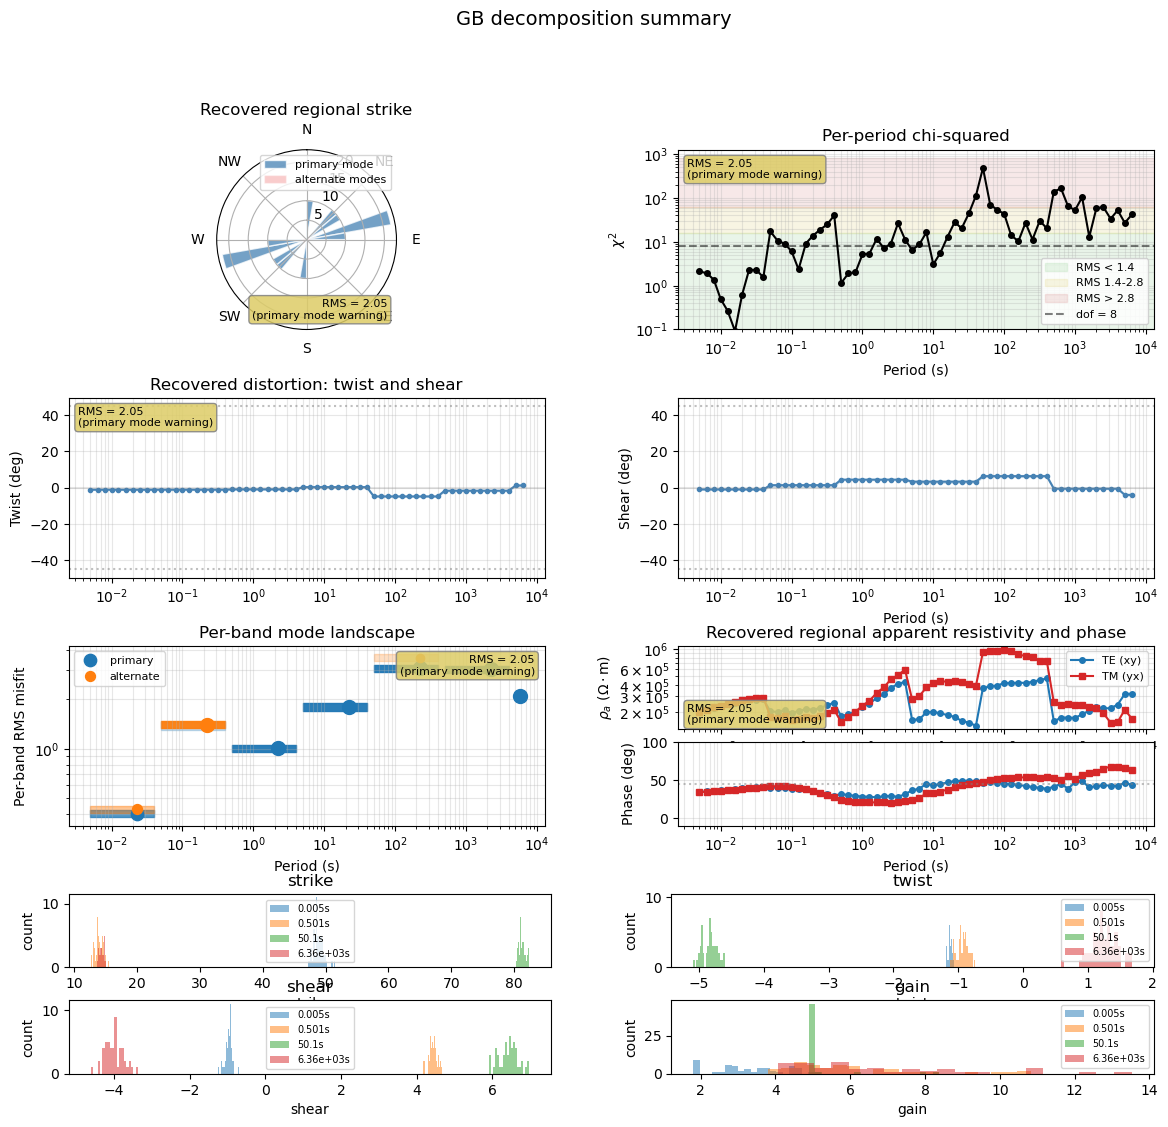

In [14]:
vulcan_result, source = load_real_or_fallback("Vulcan_2022", "vulcan_single_site.pkl")
if vulcan_result is None:
    print("Vulcan: skipped (no data, no fallback)")
else:
    print(f"Vulcan ({source}):")
    print(f"  RMS misfit: {vulcan_result.rms_misfit:.3g}")
    print(f"  Median strike: {float(vulcan_result.parameters['strike'].median()):.2f} deg")
    print(f"  Bands: {vulcan_result.metadata['n_bands']}")
    print(f"  Mode warning: {vulcan_result.metadata['primary_mode_warning']}")
    fig = plot_decomposition_summary(vulcan_result)
    plt.show()

Burra (saved example result):
  RMS misfit: 4.3  (heavily distorted; expect 2-4)
  Median strike: 26.40 deg
  Bands: 7
  Mode warning: True


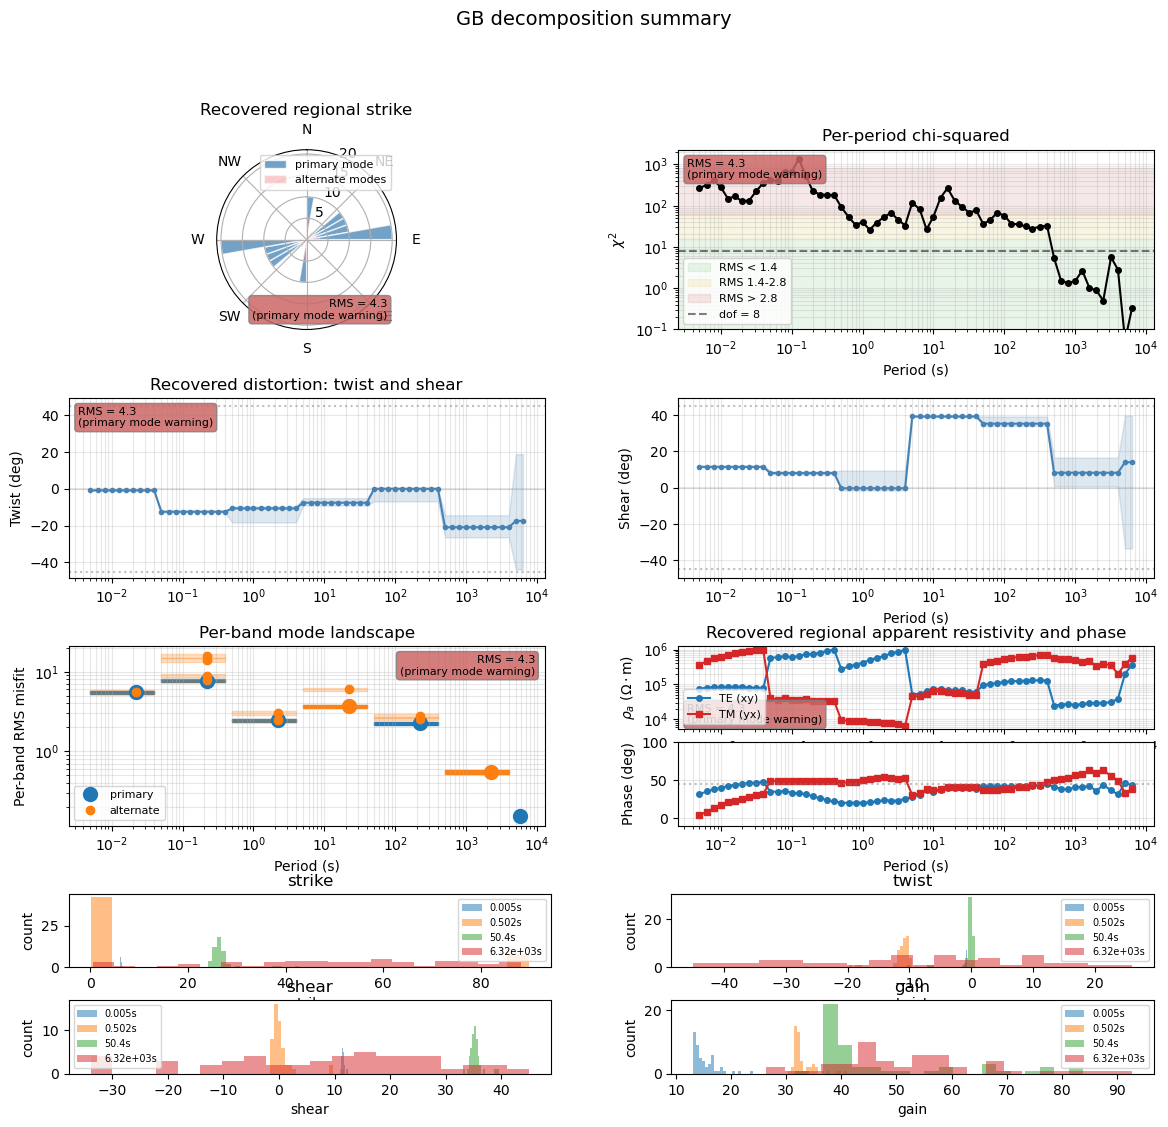

In [15]:
burra_result, source = load_real_or_fallback("Burra_2017-18", "burra_single_site.pkl")
if burra_result is None:
    print("Burra: skipped (no data, no fallback)")
else:
    print(f"Burra ({source}):")
    print(f"  RMS misfit: {burra_result.rms_misfit:.3g}  (heavily distorted; expect 2-4)")
    print(f"  Median strike: {float(burra_result.parameters['strike'].median()):.2f} deg")
    print(f"  Bands: {burra_result.metadata['n_bands']}")
    print(f"  Mode warning: {burra_result.metadata['primary_mode_warning']}")
    fig = plot_decomposition_summary(burra_result)
    plt.show()

Kalkaroo (saved example result):
  RMS misfit: 2.25
  Median strike: 57.51 deg
  Bands: 6
  Mode warning: True


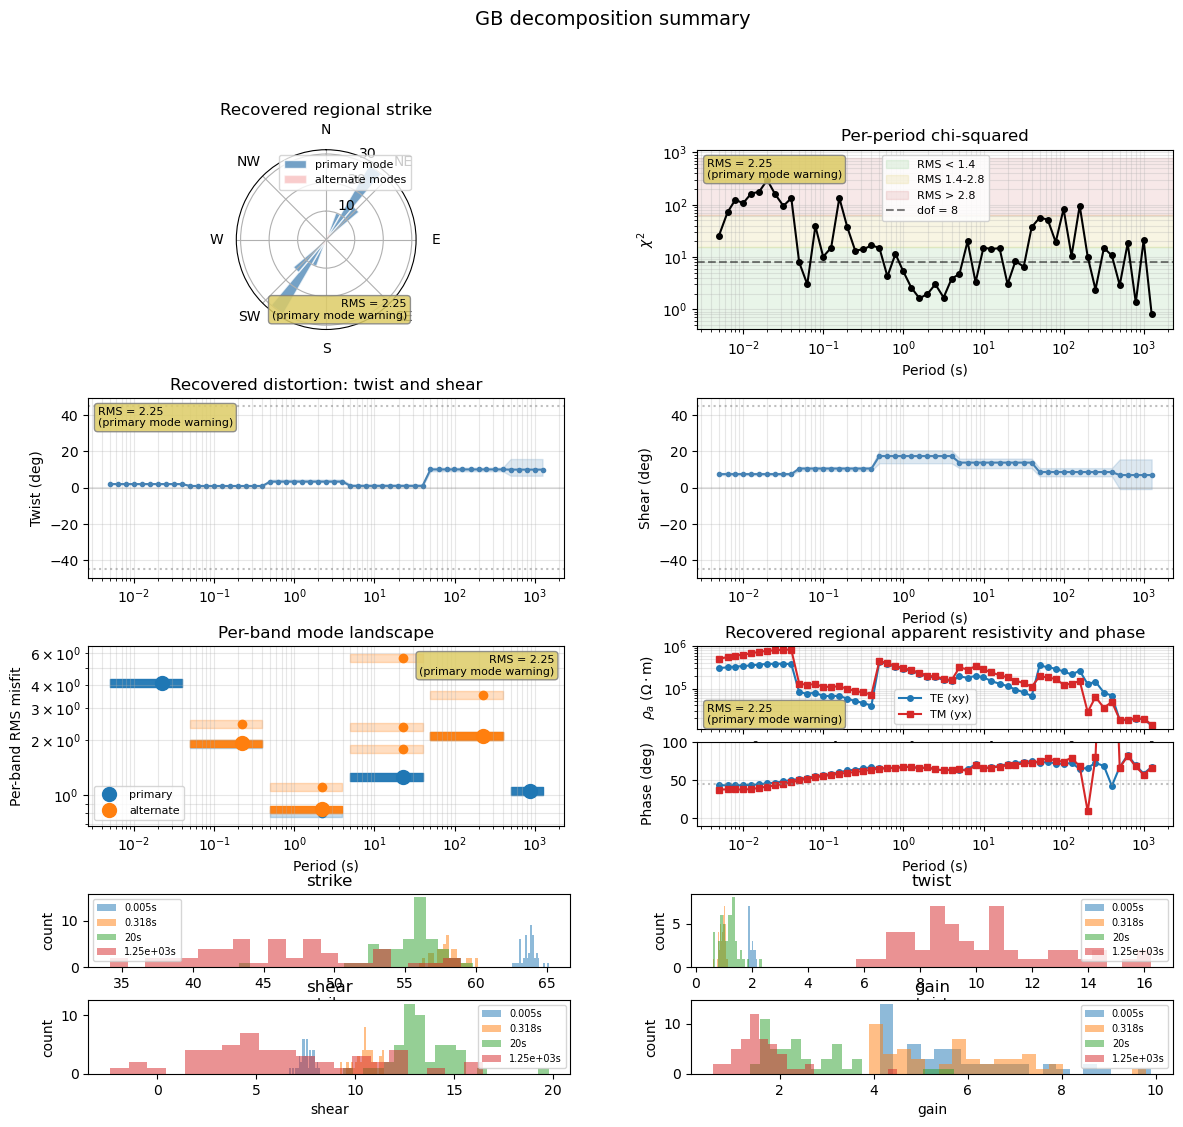

In [16]:
kalkaroo_result, source = load_real_or_fallback("Kalkaroo_2022", "kalkaroo_single_site.pkl")
if kalkaroo_result is None:
    print("Kalkaroo: skipped (no data, no fallback)")
else:
    print(f"Kalkaroo ({source}):")
    print(f"  RMS misfit: {kalkaroo_result.rms_misfit:.3g}")
    print(f"  Median strike: {float(kalkaroo_result.parameters['strike'].median()):.2f} deg")
    print(f"  Bands: {kalkaroo_result.metadata['n_bands']}")
    print(f"  Mode warning: {kalkaroo_result.metadata['primary_mode_warning']}")
    fig = plot_decomposition_summary(kalkaroo_result)
    plt.show()

Three observations from this section that bear on real-world use:

1. **Mode warnings fire on every real dataset.** Multi-modal landscapes are the rule, not the exception. The plot designs make alternate-mode information visible by default rather than hiding it as edge-case metadata.
2. **RMS in the 2-4 range is common.** Real BBMT data routinely lands above the synthetic-fit regime, often signalling that the GB89 model is underspecified (3-D effects, non-Gaussian noise). Bootstrap CIs from such fits are sensitivity bands under the assumed noise model, not honest uncertainty bands.
3. **Ragged frequency grids prevent joint fitting on real surveys.** Out of the box, `decompose_joint` requires a common grid; in practice that means most surveys need pre-resampling, or per-station analysis via `decompose_each_station`.

## 7. Save and load

Long-running decompositions (joint + bootstrap takes hours on real data) should be saved once and replotted from disk. Two formats are supported:

- `result.save(path)` / `DecompositionResult.load(path)` — pickle. Fast, faithful round-trip; not robust across Python or mtpy-v2 version changes.
- `result.to_netcdf(path)` / `DecompositionResult.from_netcdf(path)` — flat NetCDF + sidecar JSON. Slower, larger; robust archival across versions.

Both round-trip the parameters Dataset, regional impedance, chi-squared, metadata (including bootstrap replicate arrays), and scalar fields (method, frame, RMS misfit).

In [17]:
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    pkl_path = Path(tmpdir) / "result.pkl"
    nc_path = Path(tmpdir) / "result.nc"

    result_bs.save(pkl_path)
    loaded_pkl = DecompositionResult.load(pkl_path)
    print(f"Pickle: {pkl_path.stat().st_size / 1024:.1f} KB")

    result_bs.to_netcdf(nc_path)
    sidecar = nc_path.parent / (nc_path.name + ".metadata.json")
    nc_size_kb = (nc_path.stat().st_size + sidecar.stat().st_size) / 1024
    loaded_nc = DecompositionResult.from_netcdf(nc_path)
    print(f"NetCDF + sidecar JSON: {nc_size_kb:.1f} KB")

    np.testing.assert_array_equal(
        result_bs.parameters['strike'].values,
        loaded_pkl.parameters['strike'].values,
    )
    print("Pickle round-trip: ok")
    np.testing.assert_array_equal(
        result_bs.parameters['strike'].values,
        loaded_nc.parameters['strike'].values,
    )
    print("NetCDF round-trip: ok")

26:04:27T09:04:24 | INFO | line:211 |mtpy.core.transfer_function.z_analysis.decomposition | save | DecompositionResult saved to /tmp/tmpg0wolktw/result.pkl


26:04:27T09:04:24 | INFO | line:242 |mtpy.core.transfer_function.z_analysis.decomposition | load | DecompositionResult loaded from /tmp/tmpg0wolktw/result.pkl


Pickle: 162.7 KB
26:04:27T09:04:24 | INFO | line:5338 |mtpy.core.transfer_function.z_analysis.decomposition | _save_to_netcdf | DecompositionResult written to /tmp/tmpg0wolktw/result.nc (+ result.nc.metadata.json)


NetCDF + sidecar JSON: 1001.1 KB
Pickle round-trip: ok
NetCDF round-trip: ok


**Which to use.** Pickle for "save my session, restart Python, plot the same result later today" workflows. NetCDF for archival, sharing with collaborators, depositing alongside a paper, cross-version robustness. The NetCDF format uses scipy's NetCDF backend (the default in mtpy-v2's stack), so no additional dependencies are required.

## 8. Future work and limitations

### What this contribution does well

- Multi-start optimisation (canonical + 90°-rotated + perturbations) materially improves global recovery on multi-modal real data.
- Mode-aware reporting surfaces ambiguity as first-class metadata rather than hiding it.
- Parametric bootstrap (with the Chave 2014 caveat clearly documented) produces empirical CIs for direct GB parameters.
- Joint multi-site fitting reduces correctly to single-site at `n_sites=1` (verified bit-for-bit by the cornerstone test) and recovers known truth on synthetic multi-site cases.
- Validated against the Fortran reference on the canonical `strike_example` dataset: median azimuth error 6.3°, well under the 10° regression bound.

### What this contribution does not claim

- *Not a Bayesian posterior tool.* Bootstrap is frequentist resampling, not posterior sampling. Mode probabilities are Laplace approximations to local marginal likelihoods, not posterior probabilities.
- *Some quantities are gauge-equivalent or non-identifiable.* `gain` is gauge-equivalent at the band level (the forward model satisfies `(a, b, gain) -> (gain*a, gain*b, 1)`), so different starts converge to physically-equivalent solutions with different gain / |a| / |b| splits. `anisotropy` has no observable effect in the forward model and is reported with infinite error.
- *Bootstrap assumes the noise model and forward model are correct.* Model-misspecification uncertainty is not captured. CIs derived from invariant-derived quantities (phase-tensor invariants, Mohr-circle quantities) are formally meaningless per Chave (2014) and are not produced.

### Documented future-work directions

- **Regional decomposition.** Per-station-smoothed strike sharing (`strike_sharing='per_station_smoothed'`) for surveys spanning multiple geological domains. Parameter slot reserved in `decompose_joint`; raises `NotImplementedError` in this contribution.
- **Alternative mode-clustering predicates.** `mode_clustering='majority_sites_agree'` for robustness to outlier sites; `'strike_only'` when distortion is genuinely site-specific noise rather than physical signal. Slot reserved.
- **MTCollection round-trip.** `regional_z_format='mtcollection'` to return a fresh `MTCollection` instead of `dict[station_id, Z]`. Slot reserved.
- **Bayesian extensions.** Posterior sampling via HMC for direct parameters and joint-mode mixing weights would replace the Laplace approximations and bootstrap percentile CIs with proper posterior distributions. Out of scope for this contribution.
- **Per-station regional Z bootstrap CIs.** The current joint bootstrap stores per-replica strike, twist, shear, and gain but not regional Z (which would require five-dimensional arrays). Future work could store these efficiently with a sparse representation.